# 01 Load and Explore CRUTEM3

Download or load the CRUTEM3 NetCDF file, inspect its structure, select the default time period, and make first diagnostic plots.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import END_YEAR, FIGURES_DIR, START_YEAR
from src.data_loader import download_crutem3, inspect_dataset, load_crutem3
from src.preprocessing import extract_temperature_array, filter_valid_gridpoints, select_time_period, stack_gridpoints
from src.visualisation import plot_global_mean_timeseries, plot_missing_data_map

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
raw_path = download_crutem3()
ds = load_crutem3(raw_path)
inspect_dataset(ds)

Dimensions:
  t: 1973
  unspecified: 1
  latitude: 36
  longitude: 72

Coordinates:
  longitude: dims=('longitude',), shape=(72,)
  latitude: dims=('latitude',), shape=(36,)
  unspecified: dims=('unspecified',), shape=(1,)
  t: dims=('t',), shape=(1973,)

Data variables:
  temp: dims=('t', 'unspecified', 'latitude', 'longitude'), shape=(1973, 1, 36, 72) (Temperature T, K)

Inferred temperature anomaly variable: temp


"Dimensions:\n  t: 1973\n  unspecified: 1\n  latitude: 36\n  longitude: 72\n\nCoordinates:\n  longitude: dims=('longitude',), shape=(72,)\n  latitude: dims=('latitude',), shape=(36,)\n  unspecified: dims=('unspecified',), shape=(1,)\n  t: dims=('t',), shape=(1973,)\n\nData variables:\n  temp: dims=('t', 'unspecified', 'latitude', 'longitude'), shape=(1973, 1, 36, 72) (Temperature T, K)\n\nInferred temperature anomaly variable: temp"

In [3]:
ds_period = select_time_period(ds, START_YEAR, END_YEAR)
da = extract_temperature_array(ds_period)
da

<xarray.DataArray 'temp' (t: 612, latitude: 36, longitude: 72)> Size: 6MB
[1586304 values with dtype=float32]
Coordinates:
  * t          (t) datetime64[ns] 5kB 1950-01-16T12:00:00 ... 2000-12-16T12:0...
  * latitude   (latitude) float32 144B -87.5 -82.5 -77.5 ... 77.5 82.5 87.5
  * longitude  (longitude) float32 288B -177.5 -172.5 -167.5 ... 172.5 177.5
Attributes:
    source:     No field processing
    name:       temp
    title:      Temperature T
    date:       01/01/50
    time:       00:00
    long_name:  Temperature T
    units:      K
    valid_min:  -20.9
    valid_max:  19.5

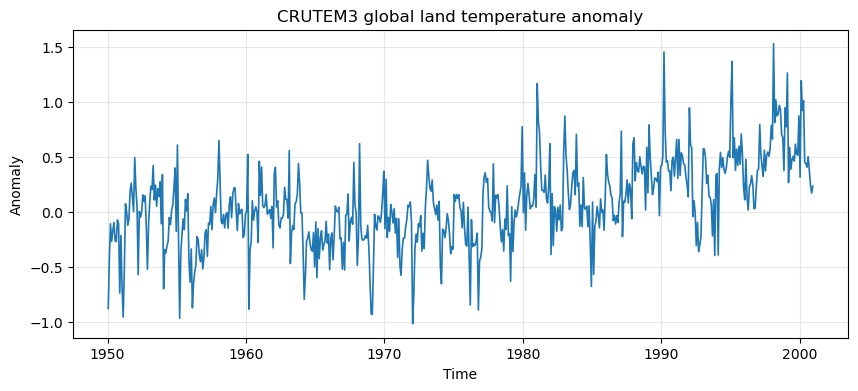

In [4]:
plot_global_mean_timeseries(da, save_path=FIGURES_DIR / "global_mean_timeseries.png");

Raw matrix: (612, 2592)
After missing-value filter: (612, 723)


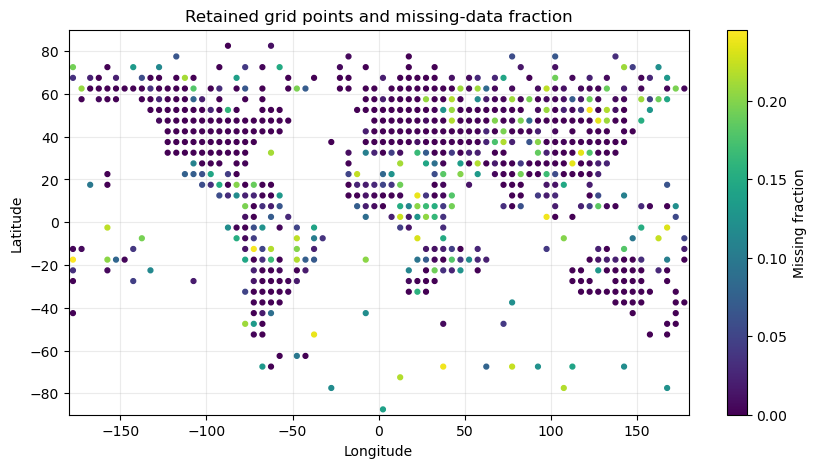

In [5]:
X, lat_lon = stack_gridpoints(da)
X_valid, lat_lon_valid = filter_valid_gridpoints(X, lat_lon)
print(f"Raw matrix: {X.shape}")
print(f"After missing-value filter: {X_valid.shape}")
plot_missing_data_map(lat_lon_valid, save_path=FIGURES_DIR / "retained_gridpoints_missing_fraction.png");